## **Import Libraries**




In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




# Load dataset and display the first few rows



In [56]:
from google.colab import files
uploaded = files.upload()

import io
data = pd.read_csv(io.BytesIO(uploaded['Housing-1.csv']))


Saving Housing-1.csv to Housing-1.csv


### Data Preprocessing

In [57]:
categorical_features = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning',
    'prefarea', 'furnishingstatus'
]

label_enc = LabelEncoder()
for feature in categorical_features:
    data[feature] = label_enc.fit_transform(data[feature])

# Drop rows with missing values
data.dropna(inplace=True)

# Normalize the area and price features
data['area'] = StandardScaler().fit_transform(data[['area']])
target_scaler = StandardScaler()
data['price'] = target_scaler.fit_transform(data[['price']])

# Define features and target
features = data.drop(columns=['price']).values
target = data['price'].values

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

### Define the Neural Network Model

In [63]:
class CustomRegressionModel(nn.Module):
    def __init__(self):
        super(CustomRegressionModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


## Train the Model




In [70]:
model = CustomRegressionModel()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, X_train, y_train, num_epochs=800):
    model.train()
    for epoch in range(num_epochs):
        inputs = torch.tensor(X_train, dtype=torch.float32)
        targets = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad()
        predictions = model(inputs)
        loss = loss_function(predictions, targets)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

train_model(model, X_train, y_train)



Epoch 50/800, Loss: 0.3351
Epoch 100/800, Loss: 0.2076
Epoch 150/800, Loss: 0.1558
Epoch 200/800, Loss: 0.1230
Epoch 250/800, Loss: 0.1006
Epoch 300/800, Loss: 0.0768
Epoch 350/800, Loss: 0.0629
Epoch 400/800, Loss: 0.0544
Epoch 450/800, Loss: 0.0470
Epoch 500/800, Loss: 0.0411
Epoch 550/800, Loss: 0.0389
Epoch 600/800, Loss: 0.0360
Epoch 650/800, Loss: 0.0329
Epoch 700/800, Loss: 0.0299
Epoch 750/800, Loss: 0.0293
Epoch 800/800, Loss: 0.0262


## Evaluate the Model



In [71]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    y_pred = model(X_test_tensor).numpy().flatten()
    y_pred_actual = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


## Model Evaluation

In [72]:


model.eval()  # Set model to evaluation mode

# Predict on the test set
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = y_pred.numpy()
    y_test_np = y_test_tensor.numpy()

# Calculate evaluation metrics
mse = mean_squared_error(y_test_np, y_pred)
mae = mean_absolute_error(y_test_np, y_pred)
r2 = r2_score(y_test_np, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')



MSE: 0.5419
MAE: 0.5403
R2 Score: 0.6256


## Calculate Metrics




In [73]:
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

# Print the evaluation metrics
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

MSE: 1892516989588.1663
MAE: 1009612.2064
R² Score: 0.6256


## Normalize features using StandardScaler

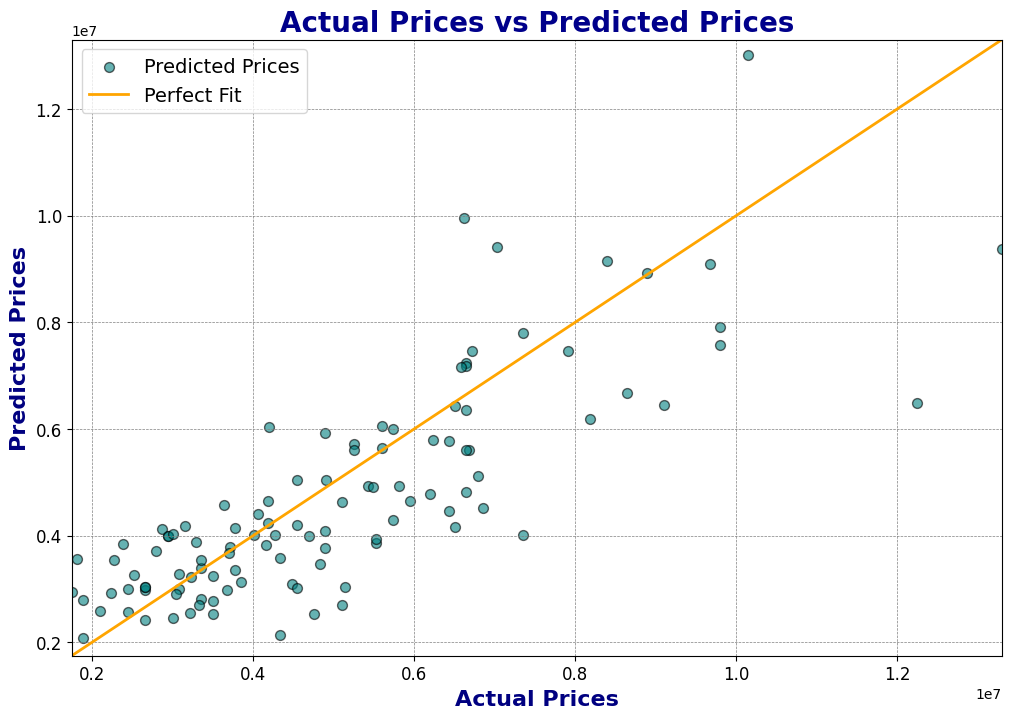

In [75]:
# Cell 8: Visualize the Results
import matplotlib.pyplot as plt

# Customizing the plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test_actual, y_pred_actual, color='teal', s=50, alpha=0.6, label='Predicted Prices', edgecolor='black')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='orange', linestyle='-', linewidth=2, label='Perfect Fit')

plt.title('Actual Prices vs Predicted Prices', fontsize=20, fontweight='bold', color='darkblue')
plt.xlabel('Actual Prices', fontsize=16, fontweight='bold', color='navy')
plt.ylabel('Predicted Prices', fontsize=16, fontweight='bold', color='navy')
plt.legend(fontsize=14)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.xlim(y_test_actual.min(), y_test_actual.max())
plt.ylim(y_test_actual.min(), y_test_actual.max())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

